# Benchmark Comparison: DP vs No-DP TT Methods

This notebook compares:
1. `yoni_laptop_no_dp_benchmark_tt.csv` - No DP benchmark
2. `yoni_laptop_dp_benchmark_tt.csv` - DP benchmark
3. `TT_j30_opt_converted.csv` - Reference file (converted from TT_j30_opt.xlsx)

## Analysis includes:
- Makespan validation across all 3 files (for problems finished in all 3)
- Problems solved in yoni files but NOT in reference file
- Problems where only DP finished vs only No-DP finished
- Expand number comparison when neither finished (with percentages)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11

DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), "data")
if not os.path.exists(DATA_PATH):
    DATA_PATH = "../data"
print(f"Data path: {DATA_PATH}")

Data path: /Users/jonathantoaf/Documents/bar-ilan/final-project/code/RCPSP_With_Petri_Nets/data


## 1. Load Data

In [2]:
df_no_dp = pd.read_csv(os.path.join(DATA_PATH, "yoni_laptop_no_dp_benchmark_tt.csv"))
df_dp = pd.read_csv(os.path.join(DATA_PATH, "yoni_laptop_dp_benchmark_tt.csv"))
df_ref = pd.read_csv(os.path.join(DATA_PATH, "TT_j30_opt_converted.csv"))

for df in [df_no_dp, df_dp, df_ref]:
    if df['finished'].dtype == object:
        df['finished'] = df['finished'].str.upper() == 'TRUE'
    else:
        df['finished'] = df['finished'].astype(bool)

print("Data loaded successfully!")
print(f"No-DP: {len(df_no_dp)} rows, {df_no_dp['finished'].sum()} finished")
print(f"DP: {len(df_dp)} rows, {df_dp['finished'].sum()} finished")
print(f"Reference (TT_j30_opt): {len(df_ref)} rows, {df_ref['finished'].sum()} finished")

Data loaded successfully!
No-DP: 480 rows, 395 finished
DP: 480 rows, 399 finished
Reference (TT_j30_opt): 480 rows, 412 finished


## 2. Makespan Validation Across All 3 Files

In [3]:
merged = pd.merge(
    df_no_dp[['group', 'exam', 'finished', 'makespan', 'expand_number', 'time']],
    df_dp[['group', 'exam', 'finished', 'makespan', 'expand_number', 'time']],
    on=['group', 'exam'], suffixes=('_no_dp', '_dp'))

merged = pd.merge(merged, df_ref[['group', 'exam', 'finished', 'makespan']],
    on=['group', 'exam'], how='left')
merged = merged.rename(columns={'finished': 'finished_ref', 'makespan': 'makespan_ref'})
merged['finished_ref'] = merged['finished_ref'].fillna(False)

all_three_finished = merged[
    (merged['finished_no_dp'] == True) & 
    (merged['finished_dp'] == True) &
    (merged['finished_ref'] == True)].copy()

all_three_finished['all_match'] = (
    (all_three_finished['makespan_no_dp'] == all_three_finished['makespan_dp']) &
    (all_three_finished['makespan_dp'] == all_three_finished['makespan_ref']))

print("="*70)
print("MAKESPAN VALIDATION (All 3 files)")
print("="*70)
print(f"Problems finished in ALL THREE: {len(all_three_finished)}")
print(f"All 3 makespans match: {all_three_finished['all_match'].sum()}")
print(f"Mismatches: {(~all_three_finished['all_match']).sum()}")

if all_three_finished['all_match'].all():
    print("\n*** SUCCESS: All makespans match! ***")
else:
    print("\n*** WARNING: Mismatches found! ***")
    display(all_three_finished[~all_three_finished['all_match']][['group', 'exam', 'makespan_no_dp', 'makespan_dp', 'makespan_ref']])

MAKESPAN VALIDATION (All 3 files)
Problems finished in ALL THREE: 394
All 3 makespans match: 394
Mismatches: 0

*** SUCCESS: All makespans match! ***


In [4]:
either_solved_ref_not = merged[
    ((merged['finished_no_dp'] == True) | (merged['finished_dp'] == True)) & 
    (merged['finished_ref'] == False)]

print("="*70)
print("PROBLEMS SOLVED IN YONI BUT NOT IN REFERENCE")
print("="*70)
print(f"Either solved but Reference didn't: {len(either_solved_ref_not)} problems")

if len(either_solved_ref_not) > 0:
    display_df = either_solved_ref_not[['group', 'exam', 'finished_no_dp', 'finished_dp', 'makespan_no_dp', 'makespan_dp']].copy()
    display_df['solved_by'] = display_df.apply(
        lambda x: 'Both' if x['finished_no_dp'] and x['finished_dp'] 
        else ('No-DP only' if x['finished_no_dp'] else 'DP only'), axis=1)
    display(display_df.sort_values(['group', 'exam']))
    print("\nBreakdown:")
    print(display_df['solved_by'].value_counts())

PROBLEMS SOLVED IN YONI BUT NOT IN REFERENCE
Either solved but Reference didn't: 0 problems


In [5]:
merged['category'] = 'Unknown'
merged.loc[(merged['finished_no_dp'] == True) & (merged['finished_dp'] == True), 'category'] = 'Both Finished'
merged.loc[(merged['finished_no_dp'] == True) & (merged['finished_dp'] == False), 'category'] = 'Only No-DP Finished'
merged.loc[(merged['finished_no_dp'] == False) & (merged['finished_dp'] == True), 'category'] = 'Only DP Finished'
merged.loc[(merged['finished_no_dp'] == False) & (merged['finished_dp'] == False), 'category'] = 'Neither Finished'

category_counts = merged['category'].value_counts()
total = len(merged)

print("="*70)
print("PROBLEM CATEGORIES: DP vs No-DP")
print("="*70)
for cat in ['Both Finished', 'Only DP Finished', 'Only No-DP Finished', 'Neither Finished']:
    count = category_counts.get(cat, 0)
    print(f"  {cat}: {count} ({count/total*100:.1f}%)")

PROBLEM CATEGORIES: DP vs No-DP
  Both Finished: 394 (82.1%)
  Only DP Finished: 5 (1.0%)
  Only No-DP Finished: 1 (0.2%)
  Neither Finished: 80 (16.7%)


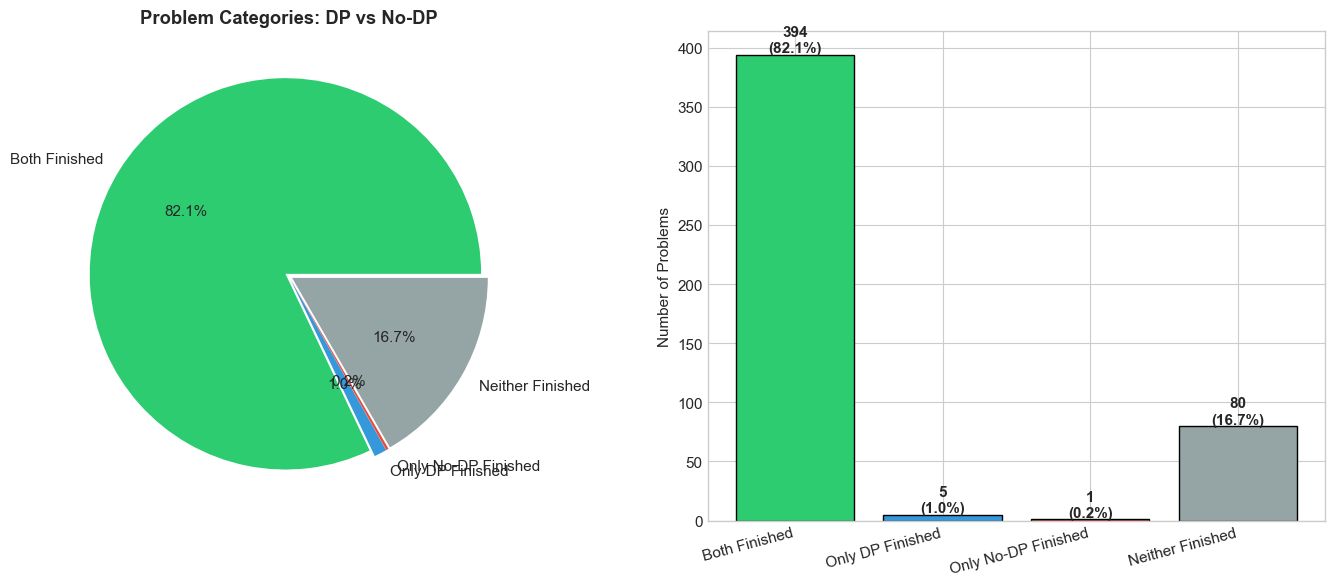

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
category_order = ['Both Finished', 'Only DP Finished', 'Only No-DP Finished', 'Neither Finished']
counts = [category_counts.get(cat, 0) for cat in category_order]

axes[0].pie(counts, labels=category_order, autopct='%1.1f%%', colors=colors, explode=(0.02, 0.02, 0.02, 0.02))
axes[0].set_title('Problem Categories: DP vs No-DP', fontweight='bold')

bars = axes[1].bar(range(len(counts)), counts, color=colors, edgecolor='black')
axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels(category_order, rotation=15, ha='right')
axes[1].set_ylabel('Number of Problems')
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{count}\n({count/total*100:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
only_dp = merged[merged['category'] == 'Only DP Finished']
only_no_dp = merged[merged['category'] == 'Only No-DP Finished']

print(f"ONLY DP FINISHED: {len(only_dp)} problems")
if len(only_dp) > 0:
    display(only_dp[['group', 'exam', 'makespan_dp', 'time_dp', 'expand_number_dp', 'time_no_dp', 'expand_number_no_dp']].sort_values(['group', 'exam']))

print(f"\nONLY No-DP FINISHED: {len(only_no_dp)} problems")
if len(only_no_dp) > 0:
    display(only_no_dp[['group', 'exam', 'makespan_no_dp', 'time_no_dp', 'expand_number_no_dp', 'time_dp', 'expand_number_dp']].sort_values(['group', 'exam']))

ONLY DP FINISHED: 5 problems


,group,exam,makespan_dp,time_dp,expand_number_dp,time_no_dp,expand_number_no_dp
130,14,1,50,34.0107,2759693,468.177,2211642
205,21,6,76,200.0650,7192337,300.000,7050942
362,37,3,81,13.9347,1082864,982.256,580092
363,37,4,83,187.8410,10700470,1052.140,3163017
417,42,8,82,27.3940,2493657,341.021,2135160



ONLY No-DP FINISHED: 1 problems


,group,exam,makespan_no_dp,time_no_dp,expand_number_no_dp,time_dp,expand_number_dp
295,30,6,62,42.5796,2158371,922.234,341496


## 3. Expand Number Analysis: Neither Finished

In [8]:
neither_finished = merged[merged['category'] == 'Neither Finished'].copy()
print(f"Total problems not finished in both: {len(neither_finished)}")

if len(neither_finished) > 0:
    neither_finished['expand_diff'] = neither_finished['expand_number_dp'] - neither_finished['expand_number_no_dp']
    neither_finished['expand_ratio'] = neither_finished['expand_number_dp'] / neither_finished['expand_number_no_dp']
    neither_finished['dp_expanded_more'] = neither_finished['expand_number_dp'] > neither_finished['expand_number_no_dp']
    neither_finished['no_dp_expanded_more'] = neither_finished['expand_number_no_dp'] > neither_finished['expand_number_dp']
    neither_finished['equal_expand'] = neither_finished['expand_number_dp'] == neither_finished['expand_number_no_dp']
    
    dp_more = neither_finished['dp_expanded_more'].sum()
    no_dp_more = neither_finished['no_dp_expanded_more'].sum()
    equal = neither_finished['equal_expand'].sum()
    total_neither = len(neither_finished)
    
    print(f"\nWHO EXPANDED MORE NODES?")
    print(f"  DP expanded more: {dp_more} ({dp_more/total_neither*100:.1f}%)")
    print(f"  No-DP expanded more: {no_dp_more} ({no_dp_more/total_neither*100:.1f}%)")
    print(f"  Equal: {equal} ({equal/total_neither*100:.1f}%)")
    print(f"\nAverage ratio (DP/No-DP): {neither_finished['expand_ratio'].mean():.3f}")
else:
    dp_more = no_dp_more = equal = total_neither = 0
    print("No problems where neither finished!")

Total problems not finished in both: 80

WHO EXPANDED MORE NODES?
  DP expanded more: 60 (75.0%)
  No-DP expanded more: 20 (25.0%)
  Equal: 0 (0.0%)

Average ratio (DP/No-DP): 3.026


/var/folders/nc/mx08jz596z744wq53r60nq480000gn/T/ipykernel_20835/985315767.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1,1].boxplot([neither_finished['expand_number_no_dp'], neither_finished['expand_number_dp']], labels=['No-DP', 'DP'], patch_artist=True)


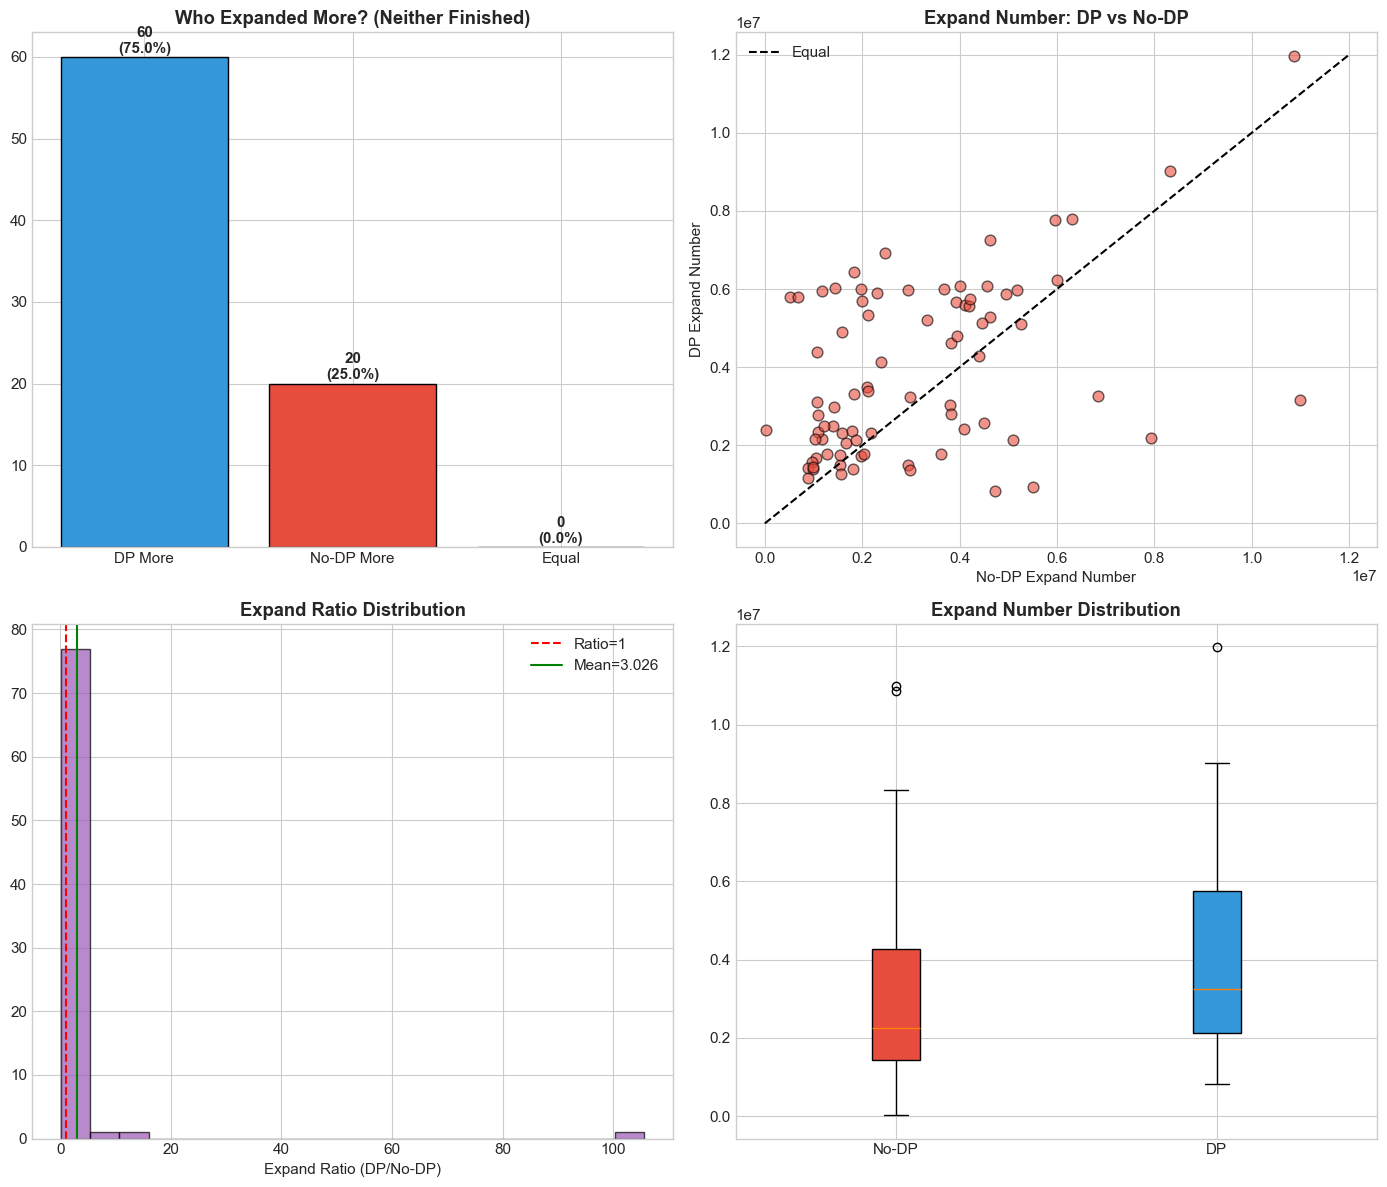

In [9]:
if len(neither_finished) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # Bar chart
    bars = axes[0,0].bar(['DP More', 'No-DP More', 'Equal'], [dp_more, no_dp_more, equal], color=['#3498db', '#e74c3c', '#95a5a6'], edgecolor='black')
    for bar, val in zip(bars, [dp_more, no_dp_more, equal]):
        axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val}\n({val/total_neither*100:.1f}%)', ha='center', fontweight='bold')
    axes[0,0].set_title('Who Expanded More? (Neither Finished)', fontweight='bold')
    
    # Scatter
    axes[0,1].scatter(neither_finished['expand_number_no_dp'], neither_finished['expand_number_dp'], alpha=0.6, c='#e74c3c', edgecolors='black', s=60)
    max_exp = max(neither_finished['expand_number_no_dp'].max(), neither_finished['expand_number_dp'].max())
    axes[0,1].plot([0, max_exp], [0, max_exp], 'k--', label='Equal')
    axes[0,1].set_xlabel('No-DP Expand Number')
    axes[0,1].set_ylabel('DP Expand Number')
    axes[0,1].set_title('Expand Number: DP vs No-DP', fontweight='bold')
    axes[0,1].legend()
    
    # Histogram
    axes[1,0].hist(neither_finished['expand_ratio'], bins=20, color='#9b59b6', edgecolor='black', alpha=0.7)
    axes[1,0].axvline(x=1, color='red', linestyle='--', label='Ratio=1')
    axes[1,0].axvline(x=neither_finished['expand_ratio'].mean(), color='green', linestyle='-', label=f'Mean={neither_finished["expand_ratio"].mean():.3f}')
    axes[1,0].set_xlabel('Expand Ratio (DP/No-DP)')
    axes[1,0].set_title('Expand Ratio Distribution', fontweight='bold')
    axes[1,0].legend()
    
    # Box plot
    bp = axes[1,1].boxplot([neither_finished['expand_number_no_dp'], neither_finished['expand_number_dp']], labels=['No-DP', 'DP'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#3498db')
    axes[1,1].set_title('Expand Number Distribution', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

In [10]:
if len(neither_finished) > 0:
    print("Detailed list of problems NOT finished in both:")
    detail_df = neither_finished[['group', 'exam', 'expand_number_no_dp', 'expand_number_dp', 'expand_ratio']].copy()
    detail_df['who_expanded_more'] = neither_finished.apply(
        lambda x: 'DP' if x['dp_expanded_more'] else ('No-DP' if x['no_dp_expanded_more'] else 'Equal'), axis=1)
    detail_df['expand_ratio'] = detail_df['expand_ratio'].round(3)
    display(detail_df.sort_values(['group', 'exam']))

Detailed list of problems NOT finished in both:


,group,exam,expand_number_no_dp,expand_number_dp,expand_ratio,who_expanded_more
41,5,2,1829528,6434007,3.517,DP
42,5,3,5502737,926997,0.168,No-DP
44,5,5,4631194,7254320,1.566,DP
46,5,7,3833052,4615986,1.204,DP
47,5,8,524480,5794030,11.047,DP
...,...,...,...,...,...,...
446,45,7,5094324,2135310,0.419,No-DP
447,45,8,10992884,3168429,0.288,No-DP
448,45,9,7927287,2187542,0.276,No-DP
449,45,10,2985515,3226896,1.081,DP


## 4. Summary

In [11]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\n1. MAKESPAN VALIDATION:")
print(f"   - {len(all_three_finished)} problems finished in all 3 files")
print(f"   - {all_three_finished['all_match'].sum()} makespans match ({all_three_finished['all_match'].mean()*100:.1f}%)")
print(f"\n2. YONI SOLVED BUT REF DIDN'T: {len(either_solved_ref_not)} problems")
print(f"\n3. CATEGORIES:")
for cat in ['Both Finished', 'Only DP Finished', 'Only No-DP Finished', 'Neither Finished']:
    count = category_counts.get(cat, 0)
    print(f"   - {cat}: {count} ({count/total*100:.1f}%)")
print(f"\n4. EXPAND (Neither Finished): {len(neither_finished)} problems")
if len(neither_finished) > 0:
    print(f"   - DP expanded more: {dp_more} ({dp_more/total_neither*100:.1f}%)")
    print(f"   - No-DP expanded more: {no_dp_more} ({no_dp_more/total_neither*100:.1f}%)")
    print(f"   - Avg ratio (DP/No-DP): {neither_finished['expand_ratio'].mean():.3f}")

FINAL SUMMARY

1. MAKESPAN VALIDATION:
   - 394 problems finished in all 3 files
   - 394 makespans match (100.0%)

2. YONI SOLVED BUT REF DIDN'T: 0 problems

3. CATEGORIES:
   - Both Finished: 394 (82.1%)
   - Only DP Finished: 5 (1.0%)
   - Only No-DP Finished: 1 (0.2%)
   - Neither Finished: 80 (16.7%)

4. EXPAND (Neither Finished): 80 problems
   - DP expanded more: 60 (75.0%)
   - No-DP expanded more: 20 (25.0%)
   - Avg ratio (DP/No-DP): 3.026
